In [25]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.feature_selection import RFE
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

In [26]:
data = pd.read_csv("D:/Thesis/Model Apply 2019/cicddos2019_dataset.csv")
data.head()

,Unnamed: 0,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Class
0,0,17,216631,6,0,2088.0,0.0,393.0,321.0,348.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP,Attack
1,1,17,2,2,0,802.0,0.0,401.0,401.0,401.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP,Attack
2,2,17,48,2,0,766.0,0.0,383.0,383.0,383.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP,Attack
3,3,17,107319,4,0,1398.0,0.0,369.0,330.0,349.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP,Attack
4,4,17,107271,4,0,1438.0,0.0,389.0,330.0,359.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP,Attack


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431371 entries, 0 to 431370
Data columns (total 80 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                431371 non-null  int64  
 1   Protocol                  431371 non-null  int64  
 2   Flow Duration             431371 non-null  int64  
 3   Total Fwd Packets         431371 non-null  int64  
 4   Total Backward Packets    431371 non-null  int64  
 5   Fwd Packets Length Total  431371 non-null  float64
 6   Bwd Packets Length Total  431371 non-null  float64
 7   Fwd Packet Length Max     431371 non-null  float64
 8   Fwd Packet Length Min     431371 non-null  float64
 9   Fwd Packet Length Mean    431371 non-null  float64
 10  Fwd Packet Length Std     431371 non-null  float64
 11  Bwd Packet Length Max     431371 non-null  float64
 12  Bwd Packet Length Min     431371 non-null  float64
 13  Bwd Packet Length Mean    431371 non-null  f

In [28]:
# Write the selected column.
selected_columns = ['Total Backward Packets','Fwd Packets Length Total',
                    'Flow Packets/s','Fwd Packet Length Mean','Fwd Packets/s',
                    'Bwd Packets/s','Packet Length Min','Packet Length Mean','Flow IAT Mean',
                    'Avg Packet Size','Avg Fwd Segment Size','Subflow Fwd Bytes','Init Fwd Win Bytes','Label']

In [29]:
# Only take the selected column from the dataset.
data = data[selected_columns]
data.head()

,Total Backward Packets,Fwd Packets Length Total,Flow Packets/s,Fwd Packet Length Mean,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Mean,Flow IAT Mean,Avg Packet Size,Avg Fwd Segment Size,Subflow Fwd Bytes,Init Fwd Win Bytes,Label
0,0,2088.0,27.696867,348.0,27.696867,0.0,321.0,344.14285,43326.2,401.5,348.0,2088,-1,UDP
1,0,802.0,1000000.000000,401.0,1000000.000000,0.0,401.0,401.00000,2.0,601.5,401.0,802,-1,UDP
2,0,766.0,41666.668000,383.0,41666.668000,0.0,383.0,383.00000,48.0,574.5,383.0,766,-1,UDP
3,0,1398.0,37.272057,349.5,37.272057,0.0,330.0,345.60000,35773.0,432.0,349.5,1398,-1,UDP
4,0,1438.0,37.288734,359.5,37.288734,0.0,330.0,353.60000,35757.0,442.0,359.5,1438,-1,UDP


In [30]:
data.describe()

,Total Backward Packets,Fwd Packets Length Total,Flow Packets/s,Fwd Packet Length Mean,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Mean,Flow IAT Mean,Avg Packet Size,Avg Fwd Segment Size,Subflow Fwd Bytes,Init Fwd Win Bytes
count,431371.000000,4.313710e+05,4.313710e+05,431371.000000,4.313710e+05,4.313710e+05,431371.000000,431371.000000,4.313710e+05,431371.000000,431371.000000,4.313710e+05,431371.000000
mean,2.472021,9.416956e+03,1.266888e+05,324.915327,1.249394e+05,1.749381e+03,294.319340,332.878668,7.998733e+05,397.782367,324.915327,9.416956e+03,2354.539580
std,56.370208,3.445253e+04,4.142850e+05,268.577313,4.121369e+05,3.235972e+04,272.771405,267.658871,1.603964e+06,362.519376,268.577313,3.445253e+04,7791.804167
min,0.000000,0.000000e+00,3.392033e-02,0.000000,8.480082e-03,0.000000e+00,0.000000,0.000000,3.333333e-01,0.000000,0.000000,0.000000e+00,-1.000000
25%,0.000000,7.800000e+01,1.332938e+00,32.000000,1.332588e+00,0.000000e+00,6.000000,43.833332,4.079234e+01,54.000000,32.000000,7.800000e+01,-1.000000
50%,0.000000,2.064000e+03,1.287540e+02,428.000000,6.429421e+01,0.000000e+00,330.000000,429.953500,9.510000e+03,442.200000,428.000000,2.064000e+03,-1.000000
75%,2.000000,5.160000e+03,3.346043e+04,516.000000,2.714118e+04,7.936003e-02,516.000000,516.000000,1.000233e+06,602.000000,516.000000,5.160000e+03,250.000000
max,31700.000000,1.526642e+07,4.000000e+06,3015.290500,4.000000e+06,2.000000e+06,1472.000000,4023.945300,5.119989e+07,4025.778600,3015.290500,1.526642e+07,65535.000000


In [31]:
# To see how many record fall in each classes.
data['Label'].value_counts()

Label
DrDoS_NTP        121368
TFTP              98917
Benign            97831
Syn               49373
UDP               18090
DrDoS_UDP         10420
UDP-lag            8872
MSSQL              8523
DrDoS_MSSQL        6212
DrDoS_DNS          3669
DrDoS_SNMP         2717
LDAP               1906
DrDoS_LDAP         1440
Portmap             685
NetBIOS             644
DrDoS_NetBIOS       598
UDPLag               55
WebDDoS              51
Name: count, dtype: int64

In [32]:
import plotly.graph_objs as go
dataa = {
    "DrDoS_NTP": 121368,
    "TFTP": 98917,
    "Benign": 97831,
    "Syn": 49373,
    "UDP": 18090,
    "DrDoS_UDP": 10420,
    "UDP-lag": 8872,
    "MSSQL": 8523,
    "DrDoS_MSSQL": 6212,
    "DrDoS_DNS": 3669,
    "DrDoS_SNMP": 2717,
    "LDAP": 1906,
    "DrDoS_LDAP": 1440,
    "Portmap": 685,
    "NetBIOS": 644,
    "DrDoS_NetBIOS": 598,
    "UDPLag": 55,
    "WebDDoS": 51
}

# Extracting labels and values from the data dictionary
labels = list(dataa.keys())
values = list(dataa.values())

# Defining custom colors for each bar
colors = ['blue', 'red', 'green', 'orange', 'purple', 'pink', 'cyan', 'magenta', 'yellow', 'brown', 'lime', 'teal', 'lavender', 'maroon', 'olive', 'navy', 'silver', 'gold']

# Creating a bar plot with custom colors
fig = go.Figure(data=[go.Bar(
    x=labels,
    y=values,
    text=values,
    textposition='auto',  # Display the text on the bars
    marker_color=colors  # Assigning custom colors to each bar
)])

# Updating the layout
fig.update_layout(
    width=800,
    height=600,
    title='Class Distribution',
    yaxis_title='Number of attacks',
    xaxis_title='Attack Name',
)

# Plotting the figure
fig.show()

In [33]:
# Replace the "DDOS attack-HOIC" and "DDOS attack-LOIC-UDP" as DDoS.
data.replace(to_replace=["DrDoS_NTP","TFTP","Syn","UDP","DrDoS_UDP","UDP-lag","MSSQL","DrDoS_MSSQL","DrDoS_DNS","DrDoS_SNMP","LDAP","DrDoS_LDAP","Portmap","NetBIOS","DrDoS_NetBIOS","UDPLag","WebDDoS"], value="DDoS", inplace=True)

In [34]:
data["Label"].value_counts()

Label
DDoS      333540
Benign     97831
Name: count, dtype: int64

In [35]:
from plotly.offline import init_notebook_mode, iplot, plot
import plotly as py
import plotly.express as px
init_notebook_mode(connected=True)

fig = go.Figure(data=[
    go.Bar(name='Benign', 
           y=data["Label"].value_counts().values[1:2],
           x=['Benign'],
           text = data["Label"].value_counts()[1:2],
           orientation='v',
           textposition='outside',),
    go.Bar(name='DDoS', 
           y=data["Label"].value_counts().values[0:1],
           x=['DDoS'],
           text = data["Label"].value_counts()[0:1],
           orientation='v',
           textposition='outside',)
])
# Change the bar mode
fig.update_layout(
                  width=800,
                  height=600,
                  title=f'Class Distribution',
                  yaxis_title='Number of attacks',
                  xaxis_title='Attack Name',)
iplot(fig)

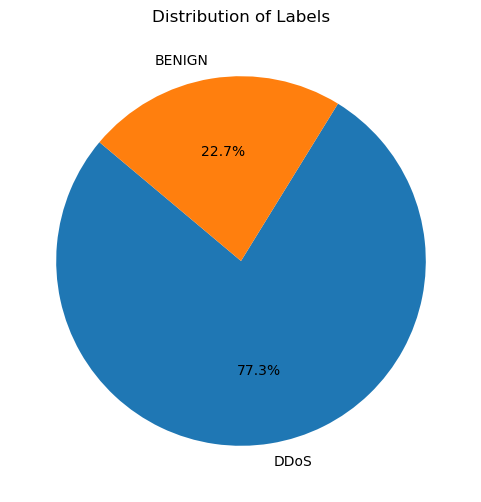

In [36]:
import matplotlib.pyplot as plt
# Assuming data is a pandas DataFrame
data1 = {'Label': ['DDoS', 'BENIGN'],
        'Count': [333540, 97831]}

# Plotting the pie chart
plt.figure(figsize=(6, 6))
plt.pie(data1['Count'], labels=data1['Label'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Labels')
plt.show()

In [37]:
x = data.iloc[:,:-1]
y = data['Label']

In [38]:
from collections import Counter
from imblearn.under_sampling import NearMiss

In [39]:
undersampling = NearMiss()

In [40]:
x_us,y_us = undersampling.fit_resample(x,y)

In [41]:
print("Orginal Dataset Shape: %s" %Counter(y))
print("After apply smote now dataset shape %s" %Counter(y_us))

Orginal Dataset Shape: Counter({'DDoS': 333540, 'Benign': 97831})
After apply smote now dataset shape Counter({'Benign': 97831, 'DDoS': 97831})


In [42]:
x_us.shape,y_us.shape

((195662, 13), (195662,))

In [43]:
# Apply the train test split.
x_train,x_test,y_train,y_test = train_test_split(x_us,y_us,test_size=0.2,stratify=y_us, random_state=15)

# Show Data After Balancing

In [44]:
labels, counts = np.unique(y_us, return_counts=True)

# Create the figure
fig = go.Figure()

# Add bars for each class
for label, count in zip(labels, counts):
    fig.add_trace(go.Bar(
        name=label,
        x=[label],
        y=[count],
        text=[count],
        textposition='outside',
        orientation='v'
    ))

# Update layout
fig.update_layout(
    width=800,
    height=600,
    title='Class Distribution after Undersampling',
    yaxis_title='Number of instances',
    xaxis_title='Class'
)

# Show the plot
iplot(fig)

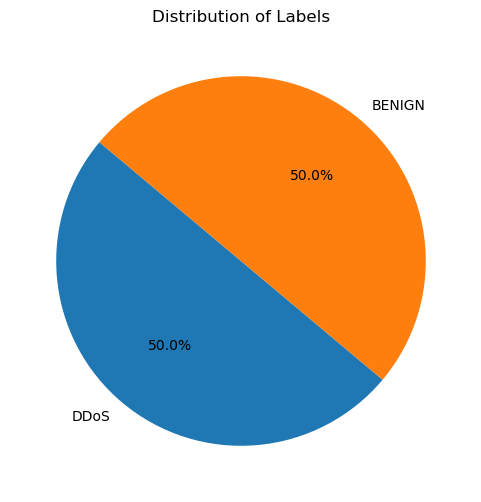

In [45]:
# Assuming data is a pandas DataFrame
data1 = {'Label': ['DDoS', 'BENIGN'],
        'Count': [97831, 97831]}

# Plotting the pie chart
plt.figure(figsize=(6, 6))
plt.pie(data1['Count'], labels=data1['Label'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Labels')
plt.show()

# Data Transformation

In [46]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [47]:
# Apply the label encoding to the target cloumn.
le = LabelEncoder()
y_train = le.fit_transform(np.ravel(y_train))
y_test = le.fit_transform(np.ravel(y_test))

In [48]:
x = scaler.fit_transform(x_us)
y = le.fit_transform(y_us)

In [49]:
x_us.shape

(195662, 13)

# Apply Model

### Gradient Boosting.

In [3]:
ProcessGradientBoosting = GradientBoostingClassifier()

In [345]:
ResultProcessGradientBoosting = cross_val_score(ProcessGradientBoosting,x,y,cv=10,verbose=2,n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:  4.9min remaining:  2.1min
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  5.8min finished


In [346]:
print(ResultProcessGradientBoosting.mean()*100)

99.28756794976152


In [245]:
x_train.shape,x_test.shape

((156529, 13), (39133, 13))

In [325]:
ProcessGradientBoosting.fit(x_train,y_train)

GradientBoostingClassifier()

In [326]:
yPredictGradientBoosting = ProcessGradientBoosting.predict(x_test)

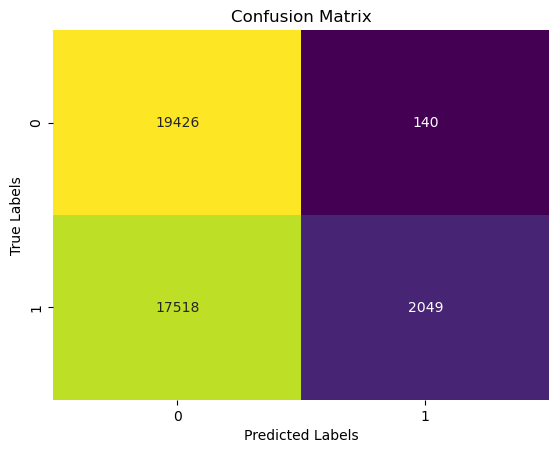

In [327]:
confMat = confusion_matrix(y_test,yPredictGradientBoosting)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [328]:
print(format(classification_report(y_test,yPredictGradientBoosting)))

              precision    recall  f1-score   support

           0       0.53      0.99      0.69     19566
           1       0.94      0.10      0.19     19567

    accuracy                           0.55     39133
   macro avg       0.73      0.55      0.44     39133
weighted avg       0.73      0.55      0.44     39133



In [329]:
print("f1 Score {}".format(f1_score(y_test,yPredictGradientBoosting)))
print("Recall Score {}".format(recall_score(y_test,yPredictGradientBoosting)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredictGradientBoosting)))
print("Precision Score {}".format(precision_score(y_test,yPredictGradientBoosting)))

f1 Score 0.18836183121897407
Recall Score 0.10471712577298513
Accuracy Score 0.5487695806608234
Precision Score 0.9360438556418456


### Random Forest

In [4]:
ProcessRandomForest = RandomForestClassifier()

In [320]:
ResultProcessRandomForest = cross_val_score(ProcessRandomForest,x,y,cv=10,verbose=2,n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:  2.0min remaining:   51.5s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  2.8min finished


In [321]:
print(ResultProcessRandomForest.mean()*100)

99.40409286066337


In [339]:
ProcessRandomForest.fit(x_train,y_train)

RandomForestClassifier()

In [340]:
yPredictRandomForest = ProcessRandomForest.predict(x_test)

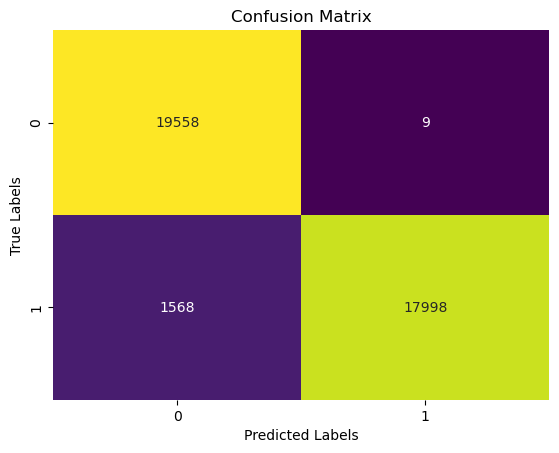

In [341]:
confMat = confusion_matrix(y_test,yPredictRandomForest)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [342]:
print(format(classification_report(y_test,yPredictRandomForest)))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96     19567
           1       1.00      0.92      0.96     19566

    accuracy                           0.96     39133
   macro avg       0.96      0.96      0.96     39133
weighted avg       0.96      0.96      0.96     39133



In [343]:
print("f1 Score {}".format(f1_score(y_test,yPredictRandomForest)))
print("Recall Score {}".format(recall_score(y_test,yPredictRandomForest)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredictRandomForest)))
print("Precision Score {}".format(precision_score(y_test,yPredictRandomForest)))

f1 Score 0.9580283714369361
Recall Score 0.9198609833384442
Accuracy Score 0.9597015306774334
Precision Score 0.9995001943688565


### CatBoosting

In [5]:
ProcessCatBoosting = CatBoostClassifier()

In [348]:
ResultProcessCatBoosting = cross_val_score(ProcessCatBoosting,x,y,cv=10,verbose=2,n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:  4.2min remaining:  1.8min
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  5.3min finished


In [349]:
print(ResultProcessCatBoosting.mean()*100)

99.42709188846008


In [264]:
ProcessCatBoosting.fit(x_train,y_train)

Learning rate set to 0.08913
0:	learn: 0.4752154	total: 90.6ms	remaining: 1m 30s
1:	learn: 0.3259373	total: 118ms	remaining: 59s
2:	learn: 0.2194529	total: 146ms	remaining: 48.7s
3:	learn: 0.1655142	total: 175ms	remaining: 43.5s
4:	learn: 0.1263436	total: 290ms	remaining: 57.7s
5:	learn: 0.1010877	total: 327ms	remaining: 54.2s
6:	learn: 0.0821203	total: 354ms	remaining: 50.3s
7:	learn: 0.0687136	total: 381ms	remaining: 47.2s
8:	learn: 0.0589943	total: 409ms	remaining: 45.1s
9:	learn: 0.0520390	total: 439ms	remaining: 43.4s
10:	learn: 0.0458742	total: 466ms	remaining: 41.9s
11:	learn: 0.0425718	total: 501ms	remaining: 41.2s
12:	learn: 0.0399944	total: 625ms	remaining: 47.4s
13:	learn: 0.0374242	total: 656ms	remaining: 46.2s
14:	learn: 0.0353408	total: 688ms	remaining: 45.2s
15:	learn: 0.0330416	total: 717ms	remaining: 44.1s
16:	learn: 0.0320530	total: 753ms	remaining: 43.5s
17:	learn: 0.0310330	total: 777ms	remaining: 42.4s
18:	learn: 0.0302005	total: 805ms	remaining: 41.6s
19:	learn: 0

162:	learn: 0.0060473	total: 6.8s	remaining: 34.9s
163:	learn: 0.0060051	total: 6.83s	remaining: 34.8s
164:	learn: 0.0059902	total: 6.89s	remaining: 34.9s
165:	learn: 0.0059788	total: 6.92s	remaining: 34.8s
166:	learn: 0.0059693	total: 6.96s	remaining: 34.7s
167:	learn: 0.0059693	total: 6.98s	remaining: 34.6s
168:	learn: 0.0059612	total: 7s	remaining: 34.4s
169:	learn: 0.0058906	total: 7.03s	remaining: 34.3s
170:	learn: 0.0058582	total: 7.06s	remaining: 34.2s
171:	learn: 0.0058337	total: 7.08s	remaining: 34.1s
172:	learn: 0.0058337	total: 7.1s	remaining: 33.9s
173:	learn: 0.0058337	total: 7.12s	remaining: 33.8s
174:	learn: 0.0058337	total: 7.14s	remaining: 33.7s
175:	learn: 0.0058337	total: 7.25s	remaining: 33.9s
176:	learn: 0.0058337	total: 7.29s	remaining: 33.9s
177:	learn: 0.0058337	total: 7.31s	remaining: 33.7s
178:	learn: 0.0058337	total: 7.33s	remaining: 33.6s
179:	learn: 0.0058303	total: 7.35s	remaining: 33.5s
180:	learn: 0.0057992	total: 7.38s	remaining: 33.4s
181:	learn: 0.005

329:	learn: 0.0053556	total: 11.4s	remaining: 23.1s
330:	learn: 0.0053556	total: 11.4s	remaining: 23s
331:	learn: 0.0053556	total: 11.4s	remaining: 23s
332:	learn: 0.0053556	total: 11.5s	remaining: 22.9s
333:	learn: 0.0053556	total: 11.5s	remaining: 22.9s
334:	learn: 0.0053556	total: 11.5s	remaining: 22.8s
335:	learn: 0.0053556	total: 11.5s	remaining: 22.8s
336:	learn: 0.0053556	total: 11.5s	remaining: 22.7s
337:	learn: 0.0053556	total: 11.6s	remaining: 22.7s
338:	learn: 0.0053556	total: 11.6s	remaining: 22.6s
339:	learn: 0.0053556	total: 11.6s	remaining: 22.6s
340:	learn: 0.0053556	total: 11.6s	remaining: 22.5s
341:	learn: 0.0053556	total: 11.7s	remaining: 22.5s
342:	learn: 0.0053556	total: 11.7s	remaining: 22.4s
343:	learn: 0.0053556	total: 11.7s	remaining: 22.3s
344:	learn: 0.0053556	total: 11.7s	remaining: 22.3s
345:	learn: 0.0053556	total: 11.8s	remaining: 22.2s
346:	learn: 0.0053556	total: 11.8s	remaining: 22.2s
347:	learn: 0.0053556	total: 11.8s	remaining: 22.1s
348:	learn: 0.00

489:	learn: 0.0053556	total: 15.3s	remaining: 16s
490:	learn: 0.0053556	total: 15.4s	remaining: 15.9s
491:	learn: 0.0053556	total: 15.4s	remaining: 15.9s
492:	learn: 0.0053556	total: 15.4s	remaining: 15.9s
493:	learn: 0.0053556	total: 15.4s	remaining: 15.8s
494:	learn: 0.0053556	total: 15.5s	remaining: 15.8s
495:	learn: 0.0053556	total: 15.5s	remaining: 15.7s
496:	learn: 0.0053556	total: 15.5s	remaining: 15.7s
497:	learn: 0.0053556	total: 15.5s	remaining: 15.7s
498:	learn: 0.0053556	total: 15.6s	remaining: 15.6s
499:	learn: 0.0053556	total: 15.6s	remaining: 15.6s
500:	learn: 0.0053556	total: 15.6s	remaining: 15.5s
501:	learn: 0.0053556	total: 15.6s	remaining: 15.5s
502:	learn: 0.0053556	total: 15.6s	remaining: 15.5s
503:	learn: 0.0053556	total: 15.7s	remaining: 15.4s
504:	learn: 0.0053556	total: 15.7s	remaining: 15.4s
505:	learn: 0.0053556	total: 15.7s	remaining: 15.4s
506:	learn: 0.0053556	total: 15.7s	remaining: 15.3s
507:	learn: 0.0053556	total: 15.8s	remaining: 15.3s
508:	learn: 0.

652:	learn: 0.0053556	total: 19.1s	remaining: 10.1s
653:	learn: 0.0053556	total: 19.1s	remaining: 10.1s
654:	learn: 0.0053556	total: 19.1s	remaining: 10.1s
655:	learn: 0.0053556	total: 19.2s	remaining: 10s
656:	learn: 0.0053556	total: 19.2s	remaining: 10s
657:	learn: 0.0053556	total: 19.2s	remaining: 9.98s
658:	learn: 0.0053556	total: 19.2s	remaining: 9.95s
659:	learn: 0.0053556	total: 19.3s	remaining: 9.92s
660:	learn: 0.0053556	total: 19.3s	remaining: 9.88s
661:	learn: 0.0053556	total: 19.3s	remaining: 9.85s
662:	learn: 0.0053556	total: 19.3s	remaining: 9.82s
663:	learn: 0.0053556	total: 19.3s	remaining: 9.78s
664:	learn: 0.0053556	total: 19.4s	remaining: 9.75s
665:	learn: 0.0053556	total: 19.4s	remaining: 9.72s
666:	learn: 0.0053556	total: 19.4s	remaining: 9.68s
667:	learn: 0.0053556	total: 19.4s	remaining: 9.65s
668:	learn: 0.0053556	total: 19.5s	remaining: 9.62s
669:	learn: 0.0053556	total: 19.5s	remaining: 9.59s
670:	learn: 0.0053556	total: 19.5s	remaining: 9.56s
671:	learn: 0.00

811:	learn: 0.0053556	total: 22.6s	remaining: 5.23s
812:	learn: 0.0053556	total: 22.6s	remaining: 5.2s
813:	learn: 0.0053556	total: 22.6s	remaining: 5.17s
814:	learn: 0.0053556	total: 22.6s	remaining: 5.14s
815:	learn: 0.0053556	total: 22.7s	remaining: 5.11s
816:	learn: 0.0053556	total: 22.7s	remaining: 5.08s
817:	learn: 0.0053556	total: 22.7s	remaining: 5.05s
818:	learn: 0.0053556	total: 22.7s	remaining: 5.02s
819:	learn: 0.0053556	total: 22.7s	remaining: 4.99s
820:	learn: 0.0053556	total: 22.8s	remaining: 4.96s
821:	learn: 0.0053556	total: 22.8s	remaining: 4.93s
822:	learn: 0.0053556	total: 22.8s	remaining: 4.91s
823:	learn: 0.0053556	total: 22.8s	remaining: 4.88s
824:	learn: 0.0053556	total: 22.9s	remaining: 4.85s
825:	learn: 0.0053556	total: 22.9s	remaining: 4.82s
826:	learn: 0.0053556	total: 22.9s	remaining: 4.79s
827:	learn: 0.0053556	total: 22.9s	remaining: 4.76s
828:	learn: 0.0053556	total: 22.9s	remaining: 4.73s
829:	learn: 0.0053556	total: 23s	remaining: 4.7s
830:	learn: 0.00

975:	learn: 0.0053556	total: 27s	remaining: 663ms
976:	learn: 0.0053556	total: 27s	remaining: 636ms
977:	learn: 0.0053556	total: 27s	remaining: 608ms
978:	learn: 0.0053556	total: 27.1s	remaining: 581ms
979:	learn: 0.0053556	total: 27.1s	remaining: 553ms
980:	learn: 0.0053556	total: 27.2s	remaining: 526ms
981:	learn: 0.0053556	total: 27.2s	remaining: 499ms
982:	learn: 0.0053556	total: 27.3s	remaining: 472ms
983:	learn: 0.0053556	total: 27.3s	remaining: 444ms
984:	learn: 0.0053556	total: 27.3s	remaining: 416ms
985:	learn: 0.0053556	total: 27.4s	remaining: 388ms
986:	learn: 0.0053556	total: 27.4s	remaining: 361ms
987:	learn: 0.0053556	total: 27.4s	remaining: 333ms
988:	learn: 0.0053556	total: 27.4s	remaining: 305ms
989:	learn: 0.0053556	total: 27.5s	remaining: 277ms
990:	learn: 0.0053556	total: 27.5s	remaining: 250ms
991:	learn: 0.0053556	total: 27.5s	remaining: 222ms
992:	learn: 0.0053556	total: 27.5s	remaining: 194ms
993:	learn: 0.0053556	total: 27.6s	remaining: 166ms
994:	learn: 0.0053

In [265]:
yPredictCatBoosting = ProcessCatBoosting.predict(x_test)

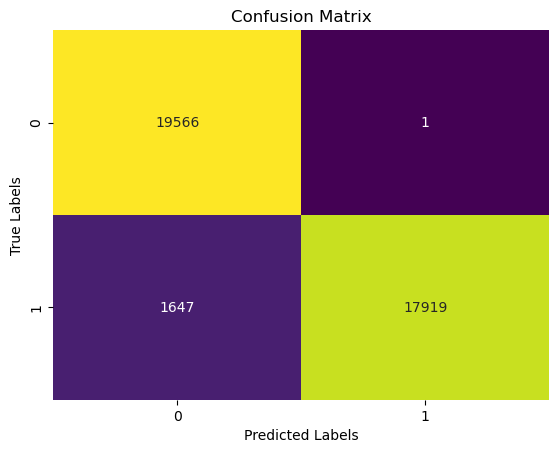

In [266]:
confMat = confusion_matrix(y_test,yPredictCatBoosting)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [267]:
print(format(classification_report(y_test,yPredictCatBoosting)))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     19567
           1       1.00      0.92      0.96     19566

    accuracy                           0.96     39133
   macro avg       0.96      0.96      0.96     39133
weighted avg       0.96      0.96      0.96     39133



In [269]:
print("f1 Score {}".format(f1_score(y_test,yPredictCatBoosting)))
print("Recall Score {}".format(recall_score(y_test,yPredictCatBoosting)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredictCatBoosting)))
print("Precision Score {}".format(precision_score(y_test,yPredictCatBoosting)))

f1 Score 0.9560369204503014
Recall Score 0.9158233670653174
Accuracy Score 0.9578872051721053
Precision Score 0.9999441964285715


### LightGBM

In [6]:
ProcessLightGBM = LGBMClassifier()

In [354]:
ResultProcessLightGBM = cross_val_score(ProcessLightGBM,x,y,verbose=2,cv=10,n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:    7.4s remaining:    3.1s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    8.1s finished


In [353]:
print(ResultProcessLightGBM.mean()*100)

99.02179527886588


In [273]:
ProcessLightGBM.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 78265, number of negative: 78264
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008911 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3277
[LightGBM] [Info] Number of data points in the train set: 156529, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500003 -> initscore=0.000013
[LightGBM] [Info] Start training from score 0.000013


LGBMClassifier()

In [274]:
yPreditLightGBM = ProcessLightGBM.predict(x_test)

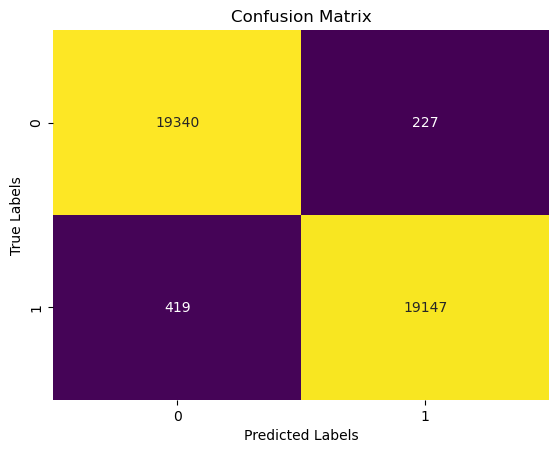

In [275]:
confMat = confusion_matrix(y_test,yPreditLightGBM)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [276]:
print(format(classification_report(y_test,yPreditLightGBM)))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     19567
           1       0.99      0.98      0.98     19566

    accuracy                           0.98     39133
   macro avg       0.98      0.98      0.98     39133
weighted avg       0.98      0.98      0.98     39133



In [277]:
print("f1 Score {}".format(f1_score(y_test,yPreditLightGBM)))
print("Recall Score {}".format(recall_score(y_test,yPreditLightGBM)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPreditLightGBM)))
print("Precision Score {}".format(precision_score(y_test,yPreditLightGBM)))

f1 Score 0.9834103749357986
Recall Score 0.9785853010324032
Accuracy Score 0.9834921932895511
Precision Score 0.9882832662330959


### AdaBoosting

In [7]:
ProcessAdaBoosting = AdaBoostClassifier()

In [280]:
ResultProcessAdaBoosting = cross_val_score(ProcessAdaBoosting,x,y,verbose=2,cv=5,n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   32.5s remaining:   48.8s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   34.3s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   34.3s finished


In [281]:
print(ResultProcessAdaBoosting.mean()*100)

98.6686367864723


In [282]:
ProcessAdaBoosting.fit(x_train,y_train)

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.



AdaBoostClassifier()

In [283]:
yPredictAdaBoosting = ProcessAdaBoosting.predict(x_test)

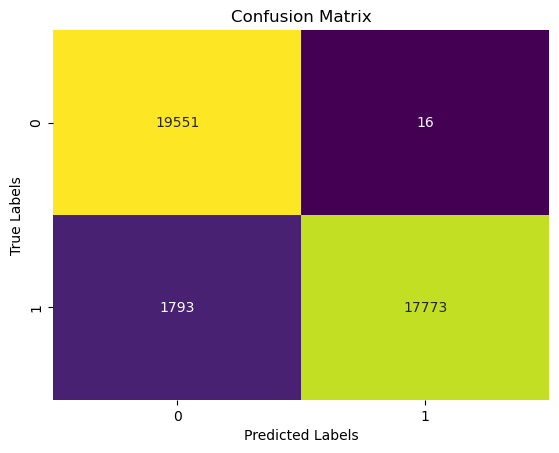

In [284]:
confMat = confusion_matrix(y_test,yPredictAdaBoosting)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [285]:
print(format(classification_report(y_test,yPredictAdaBoosting)))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     19567
           1       1.00      0.91      0.95     19566

    accuracy                           0.95     39133
   macro avg       0.96      0.95      0.95     39133
weighted avg       0.96      0.95      0.95     39133



In [286]:
print("f1 Score {}".format(f1_score(y_test,yPredictAdaBoosting)))
print("Recall Score {}".format(recall_score(y_test,yPredictAdaBoosting)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredictAdaBoosting)))
print("Precision Score {}".format(precision_score(y_test,yPredictAdaBoosting)))

f1 Score 0.9515727479587739
Recall Score 0.908361443320045
Accuracy Score 0.9537730304346715
Precision Score 0.9991005677665973


### XGBoost

In [8]:
ProcessXGBoost = XGBClassifier()

In [288]:
ResultProcessXGBoost = cross_val_score(ProcessXGBoost,x,y,cv=10,verbose=2,n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:   27.8s remaining:   11.9s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   30.5s finished


In [289]:
print(ResultProcessXGBoost.mean()*100)

99.16951486026349


In [290]:
ProcessXGBoost.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [291]:
yPredictXGBoost = ProcessXGBoost.predict(x_test)

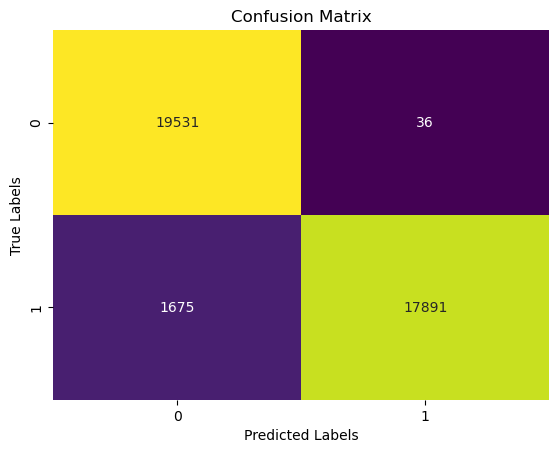

In [292]:
confMat = confusion_matrix(y_test,yPredictXGBoost)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [293]:
print(format(classification_report(y_test,yPredictXGBoost)))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     19567
           1       1.00      0.91      0.95     19566

    accuracy                           0.96     39133
   macro avg       0.96      0.96      0.96     39133
weighted avg       0.96      0.96      0.96     39133



In [294]:
print("f1 Score {}".format(f1_score(y_test,yPredictXGBoost)))
print("Recall Score {}".format(recall_score(y_test,yPredictXGBoost)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredictXGBoost)))
print("Precision Score {}".format(precision_score(y_test,yPredictXGBoost)))

f1 Score 0.9543648147654229
Recall Score 0.914392313196361
Accuracy Score 0.9562773107096313
Precision Score 0.9979918558598762


### Logistic Regression

In [9]:
ProcessLogisticRegression = LogisticRegression()

In [296]:
result = cross_val_score(ProcessLogisticRegression,x,y,cv=5,verbose=2,n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.9s remaining:    1.4s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.3s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.3s finished


In [297]:
print(result.mean()*100)

94.34890289235263


In [298]:
ProcessLogisticRegression.fit(x_train,y_train)

LogisticRegression()

In [299]:
yPredLogisticRegression = ProcessLogisticRegression.predict(x_test)

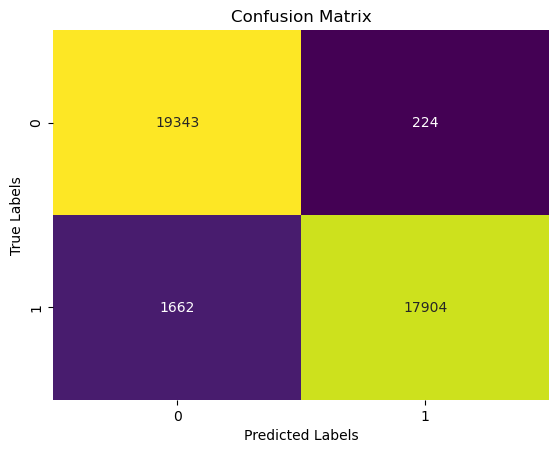

In [300]:
confMat = confusion_matrix(y_test,yPredLogisticRegression)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [301]:
print(format(classification_report(y_test,yPredLogisticRegression)))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     19567
           1       0.99      0.92      0.95     19566

    accuracy                           0.95     39133
   macro avg       0.95      0.95      0.95     39133
weighted avg       0.95      0.95      0.95     39133



In [302]:
print("f1 Score {}".format(f1_score(y_test,yPredLogisticRegression)))
print("Recall Score {}".format(recall_score(y_test,yPredLogisticRegression)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredLogisticRegression)))
print("Precision Score {}".format(precision_score(y_test,yPredLogisticRegression)))

f1 Score 0.9499655117525335
Recall Score 0.9150567310640908
Accuracy Score 0.9518053816472031
Precision Score 0.9876434245366285


### Decision Tree

In [10]:
ProcessDecisionTree = DecisionTreeClassifier()

In [304]:
ResultProcessDecisionTree = cross_val_score(ProcessDecisionTree,x,y,cv=5,verbose=2,n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    1.2s remaining:    1.9s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.4s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.4s finished


In [305]:
print(ResultProcessDecisionTree.mean()*100)

99.27937720436992


In [306]:
ProcessDecisionTree.fit(x_train,y_train)

DecisionTreeClassifier()

In [307]:
yPredDecisionTree = ProcessDecisionTree.predict(x_test)

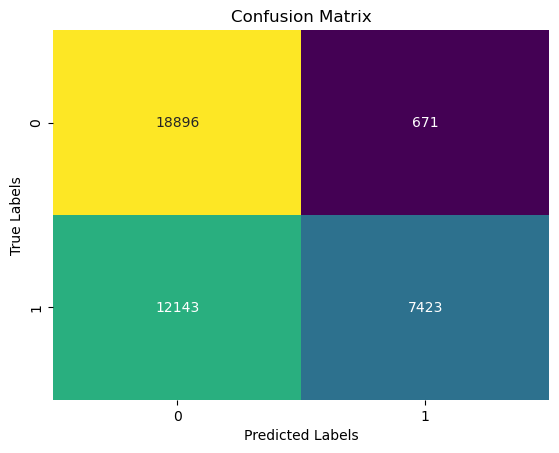

In [308]:
confMat = confusion_matrix(y_test,yPredDecisionTree)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [309]:
print(format(classification_report(y_test,yPredDecisionTree)))

              precision    recall  f1-score   support

           0       0.61      0.97      0.75     19567
           1       0.92      0.38      0.54     19566

    accuracy                           0.67     39133
   macro avg       0.76      0.67      0.64     39133
weighted avg       0.76      0.67      0.64     39133



In [310]:
print("f1 Score {}".format(f1_score(y_test,yPredDecisionTree)))
print("Recall Score {}".format(recall_score(y_test,yPredDecisionTree)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredDecisionTree)))
print("Precision Score {}".format(precision_score(y_test,yPredDecisionTree)))

f1 Score 0.5367317425885756
Recall Score 0.37938260247367883
Accuracy Score 0.672552577108834
Precision Score 0.9170990857425253


# Voting Clasifier

### Hard Voting

In [11]:
estimators = [("Ab",ProcessAdaBoosting),("Gb",ProcessGradientBoosting),("Lg",ProcessLightGBM),("Cb",ProcessCatBoosting),("Dt",ProcessDecisionTree),("Rf",ProcessRandomForest),("Xb",ProcessXGBoost)]

In [52]:
ProcessVotingClassifier = VotingClassifier(estimators=estimators,voting='hard')
result = cross_val_score(ProcessVotingClassifier,x,y,cv=10,scoring='accuracy')

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.



[LightGBM] [Info] Number of positive: 88048, number of negative: 88047
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002309 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3279
[LightGBM] [Info] Number of data points in the train set: 176095, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500003 -> initscore=0.000011
[LightGBM] [Info] Start training from score 0.000011
Learning rate set to 0.093728
0:	learn: 0.4595150	total: 39.2ms	remaining: 39.2s
1:	learn: 0.3033926	total: 73.3ms	remaining: 36.6s
2:	learn: 0.2044941	total: 105ms	remaining: 34.9s
3:	learn: 0.1431642	total: 138ms	remaining: 34.3s
4:	learn: 0.1004507	total: 184ms	remaining: 36.7s
5:	learn: 0.0749150	total: 248ms	remaining: 41s
6:	learn: 0.0614595	total: 289ms	remaining: 41s
7:	learn: 0.0476147	total: 324ms	remaining: 40.2s
8:	learn: 0.040

155:	learn: 0.0023782	total: 6.31s	remaining: 34.1s
156:	learn: 0.0023586	total: 6.41s	remaining: 34.4s
157:	learn: 0.0023370	total: 6.5s	remaining: 34.6s
158:	learn: 0.0022797	total: 6.61s	remaining: 35s
159:	learn: 0.0022796	total: 6.68s	remaining: 35.1s
160:	learn: 0.0022796	total: 6.75s	remaining: 35.2s
161:	learn: 0.0022797	total: 6.84s	remaining: 35.4s
162:	learn: 0.0022797	total: 7.24s	remaining: 37.2s
163:	learn: 0.0022796	total: 7.39s	remaining: 37.7s
164:	learn: 0.0022796	total: 7.47s	remaining: 37.8s
165:	learn: 0.0022796	total: 7.58s	remaining: 38.1s
166:	learn: 0.0022796	total: 7.67s	remaining: 38.3s
167:	learn: 0.0022795	total: 7.76s	remaining: 38.5s
168:	learn: 0.0022794	total: 7.8s	remaining: 38.4s
169:	learn: 0.0022794	total: 7.85s	remaining: 38.3s
170:	learn: 0.0022795	total: 7.89s	remaining: 38.3s
171:	learn: 0.0022794	total: 7.94s	remaining: 38.2s
172:	learn: 0.0022794	total: 7.97s	remaining: 38.1s
173:	learn: 0.0022794	total: 8.01s	remaining: 38s
174:	learn: 0.0022

315:	learn: 0.0022775	total: 13.6s	remaining: 29.4s
316:	learn: 0.0022775	total: 13.6s	remaining: 29.3s
317:	learn: 0.0022775	total: 13.6s	remaining: 29.2s
318:	learn: 0.0022775	total: 13.7s	remaining: 29.2s
319:	learn: 0.0022775	total: 13.7s	remaining: 29.1s
320:	learn: 0.0022775	total: 13.7s	remaining: 29s
321:	learn: 0.0022775	total: 13.8s	remaining: 29s
322:	learn: 0.0022775	total: 13.8s	remaining: 28.9s
323:	learn: 0.0022775	total: 13.8s	remaining: 28.8s
324:	learn: 0.0022775	total: 13.8s	remaining: 28.8s
325:	learn: 0.0022775	total: 13.9s	remaining: 28.7s
326:	learn: 0.0022775	total: 13.9s	remaining: 28.6s
327:	learn: 0.0022775	total: 13.9s	remaining: 28.6s
328:	learn: 0.0022775	total: 14s	remaining: 28.5s
329:	learn: 0.0022775	total: 14s	remaining: 28.4s
330:	learn: 0.0022775	total: 14s	remaining: 28.4s
331:	learn: 0.0022775	total: 14.1s	remaining: 28.3s
332:	learn: 0.0022775	total: 14.1s	remaining: 28.2s
333:	learn: 0.0022775	total: 14.1s	remaining: 28.2s
334:	learn: 0.0022775	

478:	learn: 0.0022775	total: 18.6s	remaining: 20.2s
479:	learn: 0.0022775	total: 18.6s	remaining: 20.2s
480:	learn: 0.0022775	total: 18.7s	remaining: 20.1s
481:	learn: 0.0022775	total: 18.7s	remaining: 20.1s
482:	learn: 0.0022775	total: 18.7s	remaining: 20s
483:	learn: 0.0022775	total: 18.8s	remaining: 20s
484:	learn: 0.0022775	total: 18.8s	remaining: 20s
485:	learn: 0.0022775	total: 18.8s	remaining: 19.9s
486:	learn: 0.0022775	total: 18.9s	remaining: 19.9s
487:	learn: 0.0022775	total: 18.9s	remaining: 19.8s
488:	learn: 0.0022775	total: 18.9s	remaining: 19.8s
489:	learn: 0.0022775	total: 18.9s	remaining: 19.7s
490:	learn: 0.0022775	total: 19s	remaining: 19.7s
491:	learn: 0.0022775	total: 19s	remaining: 19.6s
492:	learn: 0.0022775	total: 19s	remaining: 19.6s
493:	learn: 0.0022775	total: 19.1s	remaining: 19.5s
494:	learn: 0.0022775	total: 19.1s	remaining: 19.5s
495:	learn: 0.0022775	total: 19.1s	remaining: 19.4s
496:	learn: 0.0022775	total: 19.2s	remaining: 19.4s
497:	learn: 0.0022775	to

...

313:	learn: 0.0045347	total: 16.8s	remaining: 36.8s
314:	learn: 0.0045346	total: 16.9s	remaining: 36.7s
315:	learn: 0.0045346	total: 16.9s	remaining: 36.6s
316:	learn: 0.0045345	total: 16.9s	remaining: 36.5s
317:	learn: 0.0045345	total: 17s	remaining: 36.4s
318:	learn: 0.0045346	total: 17s	remaining: 36.3s
319:	learn: 0.0045346	total: 17s	remaining: 36.2s
320:	learn: 0.0045346	total: 17.1s	remaining: 36.1s
321:	learn: 0.0045346	total: 17.1s	remaining: 36s
322:	learn: 0.0045346	total: 17.1s	remaining: 35.9s
323:	learn: 0.0045346	total: 17.2s	remaining: 35.8s
324:	learn: 0.0045346	total: 17.2s	remaining: 35.7s
325:	learn: 0.0045346	total: 17.2s	remaining: 35.6s
326:	learn: 0.0045346	total: 17.3s	remaining: 35.5s
327:	learn: 0.0045346	total: 17.3s	remaining: 35.5s
328:	learn: 0.0045346	total: 17.3s	remaining: 35.4s
329:	learn: 0.0045346	total: 17.4s	remaining: 35.3s
330:	learn: 0.0045346	total: 17.4s	remaining: 35.2s
331:	learn: 0.0045346	total: 17.4s	remaining: 35.1s
332:	learn: 0.004534

476:	learn: 0.0045341	total: 22.2s	remaining: 24.3s
477:	learn: 0.0045341	total: 22.2s	remaining: 24.3s
478:	learn: 0.0045341	total: 22.3s	remaining: 24.2s
479:	learn: 0.0045341	total: 22.3s	remaining: 24.2s
480:	learn: 0.0045341	total: 22.3s	remaining: 24.1s
481:	learn: 0.0045341	total: 22.4s	remaining: 24.1s
482:	learn: 0.0045341	total: 22.4s	remaining: 24s
483:	learn: 0.0045341	total: 22.4s	remaining: 23.9s
484:	learn: 0.0045341	total: 22.5s	remaining: 23.9s
485:	learn: 0.0045341	total: 22.5s	remaining: 23.8s
486:	learn: 0.0045341	total: 22.5s	remaining: 23.7s
487:	learn: 0.0045341	total: 22.6s	remaining: 23.7s
488:	learn: 0.0045341	total: 22.6s	remaining: 23.6s
489:	learn: 0.0045341	total: 22.6s	remaining: 23.6s
490:	learn: 0.0045341	total: 22.7s	remaining: 23.5s
491:	learn: 0.0045341	total: 22.7s	remaining: 23.4s
492:	learn: 0.0045341	total: 22.7s	remaining: 23.4s
493:	learn: 0.0045341	total: 22.8s	remaining: 23.3s
494:	learn: 0.0045341	total: 22.8s	remaining: 23.3s
495:	learn: 0.

636:	learn: 0.0045340	total: 27.5s	remaining: 15.7s
637:	learn: 0.0045340	total: 27.5s	remaining: 15.6s
638:	learn: 0.0045340	total: 27.6s	remaining: 15.6s
639:	learn: 0.0045340	total: 27.6s	remaining: 15.5s
640:	learn: 0.0045340	total: 27.6s	remaining: 15.5s
641:	learn: 0.0045340	total: 27.7s	remaining: 15.4s
642:	learn: 0.0045340	total: 27.7s	remaining: 15.4s
643:	learn: 0.0045340	total: 27.7s	remaining: 15.3s
644:	learn: 0.0045340	total: 27.8s	remaining: 15.3s
645:	learn: 0.0045340	total: 27.8s	remaining: 15.2s
646:	learn: 0.0045340	total: 27.8s	remaining: 15.2s
647:	learn: 0.0045340	total: 27.9s	remaining: 15.1s
648:	learn: 0.0045340	total: 27.9s	remaining: 15.1s
649:	learn: 0.0045340	total: 27.9s	remaining: 15s
650:	learn: 0.0045340	total: 28s	remaining: 15s
651:	learn: 0.0045340	total: 28s	remaining: 14.9s
652:	learn: 0.0045340	total: 28s	remaining: 14.9s
653:	learn: 0.0045340	total: 28.1s	remaining: 14.8s
654:	learn: 0.0045340	total: 28.1s	remaining: 14.8s
655:	learn: 0.0045340	

799:	learn: 0.0045340	total: 36.9s	remaining: 9.23s
800:	learn: 0.0045340	total: 37s	remaining: 9.18s
801:	learn: 0.0045340	total: 37s	remaining: 9.13s
802:	learn: 0.0045340	total: 37s	remaining: 9.08s
803:	learn: 0.0045340	total: 37.1s	remaining: 9.03s
804:	learn: 0.0045340	total: 37.1s	remaining: 8.98s
805:	learn: 0.0045340	total: 37.1s	remaining: 8.93s
806:	learn: 0.0045340	total: 37.1s	remaining: 8.88s
807:	learn: 0.0045340	total: 37.2s	remaining: 8.84s
808:	learn: 0.0045340	total: 37.2s	remaining: 8.79s
809:	learn: 0.0045340	total: 37.2s	remaining: 8.74s
810:	learn: 0.0045340	total: 37.3s	remaining: 8.69s
811:	learn: 0.0045340	total: 37.3s	remaining: 8.64s
812:	learn: 0.0045340	total: 37.3s	remaining: 8.59s
813:	learn: 0.0045340	total: 37.4s	remaining: 8.54s
814:	learn: 0.0045340	total: 37.4s	remaining: 8.49s
815:	learn: 0.0045340	total: 37.5s	remaining: 8.45s
816:	learn: 0.0045340	total: 37.5s	remaining: 8.4s
817:	learn: 0.0045340	total: 37.5s	remaining: 8.35s
818:	learn: 0.00453

959:	learn: 0.0045340	total: 42.2s	remaining: 1.76s
960:	learn: 0.0045340	total: 42.2s	remaining: 1.71s
961:	learn: 0.0045340	total: 42.2s	remaining: 1.67s
962:	learn: 0.0045340	total: 42.3s	remaining: 1.62s
963:	learn: 0.0045340	total: 42.3s	remaining: 1.58s
964:	learn: 0.0045340	total: 42.3s	remaining: 1.53s
965:	learn: 0.0045340	total: 42.4s	remaining: 1.49s
966:	learn: 0.0045340	total: 42.4s	remaining: 1.45s
967:	learn: 0.0045340	total: 42.4s	remaining: 1.4s
968:	learn: 0.0045340	total: 42.5s	remaining: 1.36s
969:	learn: 0.0045340	total: 42.5s	remaining: 1.31s
970:	learn: 0.0045340	total: 42.5s	remaining: 1.27s
971:	learn: 0.0045340	total: 42.6s	remaining: 1.23s
972:	learn: 0.0045340	total: 42.6s	remaining: 1.18s
973:	learn: 0.0045340	total: 42.6s	remaining: 1.14s
974:	learn: 0.0045340	total: 42.6s	remaining: 1.09s
975:	learn: 0.0045340	total: 42.7s	remaining: 1.05s
976:	learn: 0.0045340	total: 42.7s	remaining: 1s
977:	learn: 0.0045340	total: 42.7s	remaining: 962ms
978:	learn: 0.00

In [53]:
print(np.mean(result)*100)

99.38518522244976


### Soft Voting

In [50]:
ProcessVotingClassifier = VotingClassifier(estimators=estimators,voting='soft')
result1 = cross_val_score(ProcessVotingClassifier,x,y,cv=10,scoring='accuracy')

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.



[LightGBM] [Info] Number of positive: 88048, number of negative: 88047
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002054 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3279
[LightGBM] [Info] Number of data points in the train set: 176095, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500003 -> initscore=0.000011
[LightGBM] [Info] Start training from score 0.000011
Learning rate set to 0.093728
0:	learn: 0.4595150	total: 178ms	remaining: 2m 58s
1:	learn: 0.3033926	total: 206ms	remaining: 1m 42s
2:	learn: 0.2044941	total: 233ms	remaining: 1m 17s
3:	learn: 0.1431642	total: 261ms	remaining: 1m 4s
4:	learn: 0.1004507	total: 288ms	remaining: 57.3s
5:	learn: 0.0749150	total: 314ms	remaining: 52s
6:	learn: 0.0614595	total: 340ms	remaining: 48.2s
7:	learn: 0.0476147	total: 366ms	remaining: 45.4s
8:	learn: 0.

158:	learn: 0.0022797	total: 4.41s	remaining: 23.3s
159:	learn: 0.0022796	total: 4.43s	remaining: 23.3s
160:	learn: 0.0022796	total: 4.45s	remaining: 23.2s
161:	learn: 0.0022797	total: 4.47s	remaining: 23.1s
162:	learn: 0.0022797	total: 4.5s	remaining: 23.1s
163:	learn: 0.0022796	total: 4.52s	remaining: 23s
164:	learn: 0.0022796	total: 4.54s	remaining: 23s
165:	learn: 0.0022796	total: 4.56s	remaining: 22.9s
166:	learn: 0.0022796	total: 4.58s	remaining: 22.9s
167:	learn: 0.0022795	total: 4.61s	remaining: 22.8s
168:	learn: 0.0022794	total: 4.63s	remaining: 22.8s
169:	learn: 0.0022794	total: 4.65s	remaining: 22.7s
170:	learn: 0.0022795	total: 4.67s	remaining: 22.7s
171:	learn: 0.0022794	total: 4.7s	remaining: 22.6s
172:	learn: 0.0022794	total: 4.72s	remaining: 22.6s
173:	learn: 0.0022794	total: 4.74s	remaining: 22.5s
174:	learn: 0.0022794	total: 4.77s	remaining: 22.5s
175:	learn: 0.0022794	total: 4.79s	remaining: 22.4s
176:	learn: 0.0022792	total: 4.81s	remaining: 22.4s
177:	learn: 0.0022

323:	learn: 0.0022775	total: 8.34s	remaining: 17.4s
324:	learn: 0.0022775	total: 8.36s	remaining: 17.4s
325:	learn: 0.0022775	total: 8.38s	remaining: 17.3s
326:	learn: 0.0022775	total: 8.41s	remaining: 17.3s
327:	learn: 0.0022775	total: 8.43s	remaining: 17.3s
328:	learn: 0.0022775	total: 8.46s	remaining: 17.2s
329:	learn: 0.0022775	total: 8.48s	remaining: 17.2s
330:	learn: 0.0022775	total: 8.51s	remaining: 17.2s
331:	learn: 0.0022775	total: 8.53s	remaining: 17.2s
332:	learn: 0.0022775	total: 8.55s	remaining: 17.1s
333:	learn: 0.0022775	total: 8.58s	remaining: 17.1s
334:	learn: 0.0022775	total: 8.6s	remaining: 17.1s
335:	learn: 0.0022775	total: 8.63s	remaining: 17.1s
336:	learn: 0.0022775	total: 8.65s	remaining: 17s
337:	learn: 0.0022775	total: 8.69s	remaining: 17s
338:	learn: 0.0022775	total: 8.71s	remaining: 17s
339:	learn: 0.0022775	total: 8.74s	remaining: 17s
340:	learn: 0.0022775	total: 8.76s	remaining: 16.9s
341:	learn: 0.0022775	total: 8.79s	remaining: 16.9s
342:	learn: 0.0022775

489:	learn: 0.0022775	total: 12.5s	remaining: 13s
490:	learn: 0.0022775	total: 12.5s	remaining: 13s
491:	learn: 0.0022775	total: 12.6s	remaining: 13s
492:	learn: 0.0022775	total: 12.6s	remaining: 13s
493:	learn: 0.0022775	total: 12.6s	remaining: 12.9s
494:	learn: 0.0022775	total: 12.7s	remaining: 12.9s
495:	learn: 0.0022775	total: 12.7s	remaining: 12.9s
496:	learn: 0.0022775	total: 12.7s	remaining: 12.9s
497:	learn: 0.0022775	total: 12.7s	remaining: 12.8s
498:	learn: 0.0022775	total: 12.8s	remaining: 12.8s
499:	learn: 0.0022775	total: 12.8s	remaining: 12.8s
500:	learn: 0.0022775	total: 12.8s	remaining: 12.8s
501:	learn: 0.0022775	total: 12.8s	remaining: 12.7s
502:	learn: 0.0022775	total: 12.8s	remaining: 12.7s
503:	learn: 0.0022775	total: 12.9s	remaining: 12.7s
504:	learn: 0.0022775	total: 12.9s	remaining: 12.6s
505:	learn: 0.0022775	total: 12.9s	remaining: 12.6s
506:	learn: 0.0022775	total: 12.9s	remaining: 12.6s
507:	learn: 0.0022775	total: 13s	remaining: 12.6s
508:	learn: 0.0022775	

...

315:	learn: 0.0045346	total: 8.23s	remaining: 17.8s
316:	learn: 0.0045345	total: 8.26s	remaining: 17.8s
317:	learn: 0.0045345	total: 8.28s	remaining: 17.8s
318:	learn: 0.0045346	total: 8.3s	remaining: 17.7s
319:	learn: 0.0045346	total: 8.33s	remaining: 17.7s
320:	learn: 0.0045346	total: 8.35s	remaining: 17.7s
321:	learn: 0.0045346	total: 8.37s	remaining: 17.6s
322:	learn: 0.0045346	total: 8.4s	remaining: 17.6s
323:	learn: 0.0045346	total: 8.42s	remaining: 17.6s
324:	learn: 0.0045346	total: 8.45s	remaining: 17.5s
325:	learn: 0.0045346	total: 8.47s	remaining: 17.5s
326:	learn: 0.0045346	total: 8.49s	remaining: 17.5s
327:	learn: 0.0045346	total: 8.52s	remaining: 17.4s
328:	learn: 0.0045346	total: 8.54s	remaining: 17.4s
329:	learn: 0.0045346	total: 8.56s	remaining: 17.4s
330:	learn: 0.0045346	total: 8.59s	remaining: 17.4s
331:	learn: 0.0045346	total: 8.61s	remaining: 17.3s
332:	learn: 0.0045346	total: 8.63s	remaining: 17.3s
333:	learn: 0.0045346	total: 8.66s	remaining: 17.3s
334:	learn: 0.

481:	learn: 0.0045341	total: 12.2s	remaining: 13.1s
482:	learn: 0.0045341	total: 12.2s	remaining: 13.1s
483:	learn: 0.0045341	total: 12.3s	remaining: 13.1s
484:	learn: 0.0045341	total: 12.3s	remaining: 13s
485:	learn: 0.0045341	total: 12.3s	remaining: 13s
486:	learn: 0.0045341	total: 12.3s	remaining: 13s
487:	learn: 0.0045341	total: 12.3s	remaining: 13s
488:	learn: 0.0045341	total: 12.4s	remaining: 12.9s
489:	learn: 0.0045341	total: 12.4s	remaining: 12.9s
490:	learn: 0.0045341	total: 12.4s	remaining: 12.9s
491:	learn: 0.0045341	total: 12.4s	remaining: 12.8s
492:	learn: 0.0045341	total: 12.5s	remaining: 12.8s
493:	learn: 0.0045341	total: 12.5s	remaining: 12.8s
494:	learn: 0.0045341	total: 12.5s	remaining: 12.8s
495:	learn: 0.0045341	total: 12.5s	remaining: 12.7s
496:	learn: 0.0045341	total: 12.6s	remaining: 12.7s
497:	learn: 0.0045341	total: 12.6s	remaining: 12.7s
498:	learn: 0.0045341	total: 12.6s	remaining: 12.7s
499:	learn: 0.0045341	total: 12.6s	remaining: 12.6s
500:	learn: 0.004534

645:	learn: 0.0045340	total: 16.1s	remaining: 8.82s
646:	learn: 0.0045340	total: 16.1s	remaining: 8.79s
647:	learn: 0.0045340	total: 16.1s	remaining: 8.77s
648:	learn: 0.0045340	total: 16.2s	remaining: 8.74s
649:	learn: 0.0045340	total: 16.2s	remaining: 8.72s
650:	learn: 0.0045340	total: 16.2s	remaining: 8.69s
651:	learn: 0.0045340	total: 16.2s	remaining: 8.66s
652:	learn: 0.0045340	total: 16.3s	remaining: 8.64s
653:	learn: 0.0045340	total: 16.3s	remaining: 8.61s
654:	learn: 0.0045340	total: 16.3s	remaining: 8.59s
655:	learn: 0.0045340	total: 16.3s	remaining: 8.56s
656:	learn: 0.0045340	total: 16.4s	remaining: 8.54s
657:	learn: 0.0045340	total: 16.4s	remaining: 8.51s
658:	learn: 0.0045340	total: 16.4s	remaining: 8.49s
659:	learn: 0.0045340	total: 16.4s	remaining: 8.46s
660:	learn: 0.0045340	total: 16.5s	remaining: 8.44s
661:	learn: 0.0045340	total: 16.5s	remaining: 8.41s
662:	learn: 0.0045340	total: 16.5s	remaining: 8.38s
663:	learn: 0.0045340	total: 16.5s	remaining: 8.36s
664:	learn: 

808:	learn: 0.0045340	total: 20s	remaining: 4.71s
809:	learn: 0.0045340	total: 20s	remaining: 4.69s
810:	learn: 0.0045340	total: 20s	remaining: 4.66s
811:	learn: 0.0045340	total: 20s	remaining: 4.64s
812:	learn: 0.0045340	total: 20.1s	remaining: 4.61s
813:	learn: 0.0045340	total: 20.1s	remaining: 4.59s
814:	learn: 0.0045340	total: 20.1s	remaining: 4.56s
815:	learn: 0.0045340	total: 20.1s	remaining: 4.54s
816:	learn: 0.0045340	total: 20.1s	remaining: 4.51s
817:	learn: 0.0045340	total: 20.2s	remaining: 4.49s
818:	learn: 0.0045340	total: 20.2s	remaining: 4.46s
819:	learn: 0.0045340	total: 20.2s	remaining: 4.44s
820:	learn: 0.0045340	total: 20.2s	remaining: 4.41s
821:	learn: 0.0045340	total: 20.3s	remaining: 4.39s
822:	learn: 0.0045340	total: 20.3s	remaining: 4.36s
823:	learn: 0.0045340	total: 20.3s	remaining: 4.34s
824:	learn: 0.0045340	total: 20.3s	remaining: 4.31s
825:	learn: 0.0045340	total: 20.4s	remaining: 4.29s
826:	learn: 0.0045340	total: 20.4s	remaining: 4.26s
827:	learn: 0.004534

967:	learn: 0.0045340	total: 23.8s	remaining: 788ms
968:	learn: 0.0045340	total: 23.9s	remaining: 763ms
969:	learn: 0.0045340	total: 23.9s	remaining: 739ms
970:	learn: 0.0045340	total: 23.9s	remaining: 714ms
971:	learn: 0.0045340	total: 23.9s	remaining: 689ms
972:	learn: 0.0045340	total: 24s	remaining: 665ms
973:	learn: 0.0045340	total: 24s	remaining: 640ms
974:	learn: 0.0045340	total: 24s	remaining: 615ms
975:	learn: 0.0045340	total: 24s	remaining: 591ms
976:	learn: 0.0045340	total: 24.1s	remaining: 566ms
977:	learn: 0.0045340	total: 24.1s	remaining: 542ms
978:	learn: 0.0045340	total: 24.1s	remaining: 517ms
979:	learn: 0.0045340	total: 24.1s	remaining: 492ms
980:	learn: 0.0045340	total: 24.1s	remaining: 468ms
981:	learn: 0.0045340	total: 24.2s	remaining: 443ms
982:	learn: 0.0045340	total: 24.2s	remaining: 418ms
983:	learn: 0.0045340	total: 24.2s	remaining: 394ms
984:	learn: 0.0045340	total: 24.2s	remaining: 369ms
985:	learn: 0.0045340	total: 24.3s	remaining: 344ms
986:	learn: 0.004534

In [51]:
print(np.mean(result1)*100)

99.39693975928122


### Stacking

In [54]:
StackEstimetors = [("Gb",ProcessGradientBoosting),("Dt",ProcessDecisionTree),("Rf",ProcessRandomForest),("Cb",ProcessCatBoosting),("Lgbm",ProcessLightGBM),("Xb",ProcessXGBoost)]

In [57]:
ProcessStacking = StackingClassifier(estimators=StackEstimetors,final_estimator=ProcessAdaBoosting,cv=5)

In [58]:
ResultProcessStacking = cross_val_score(ProcessStacking,x,y,cv=10,verbose=2,n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed: 41.2min remaining: 17.7min
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed: 51.1min finished


In [59]:
print(ResultProcessStacking.mean()*100)

99.21193104973938


In [60]:
ProcessStacking.fit(x_train,y_train)

Learning rate set to 0.08913
0:	learn: 0.4773091	total: 26.6ms	remaining: 26.6s
1:	learn: 0.3284033	total: 51.3ms	remaining: 25.6s
2:	learn: 0.2263998	total: 77.5ms	remaining: 25.8s
3:	learn: 0.1712595	total: 102ms	remaining: 25.4s
4:	learn: 0.1310192	total: 126ms	remaining: 25.1s
5:	learn: 0.1111369	total: 147ms	remaining: 24.3s
6:	learn: 0.0916857	total: 170ms	remaining: 24.1s
7:	learn: 0.0745777	total: 193ms	remaining: 23.9s
8:	learn: 0.0655796	total: 220ms	remaining: 24.3s
9:	learn: 0.0584077	total: 279ms	remaining: 27.6s
10:	learn: 0.0515797	total: 306ms	remaining: 27.5s
11:	learn: 0.0467109	total: 336ms	remaining: 27.6s
12:	learn: 0.0430152	total: 362ms	remaining: 27.5s
13:	learn: 0.0393886	total: 394ms	remaining: 27.7s
14:	learn: 0.0370744	total: 416ms	remaining: 27.3s
15:	learn: 0.0337892	total: 444ms	remaining: 27.3s
16:	learn: 0.0321664	total: 474ms	remaining: 27.4s
17:	learn: 0.0313988	total: 500ms	remaining: 27.3s
18:	learn: 0.0302481	total: 525ms	remaining: 27.1s
19:	learn

169:	learn: 0.0058349	total: 4.41s	remaining: 21.5s
170:	learn: 0.0057580	total: 4.43s	remaining: 21.5s
171:	learn: 0.0057498	total: 4.46s	remaining: 21.5s
172:	learn: 0.0057092	total: 4.48s	remaining: 21.4s
173:	learn: 0.0056949	total: 4.5s	remaining: 21.4s
174:	learn: 0.0056948	total: 4.53s	remaining: 21.3s
175:	learn: 0.0056948	total: 4.55s	remaining: 21.3s
176:	learn: 0.0056811	total: 4.57s	remaining: 21.3s
177:	learn: 0.0056464	total: 4.6s	remaining: 21.2s
178:	learn: 0.0055880	total: 4.63s	remaining: 21.2s
179:	learn: 0.0055595	total: 4.65s	remaining: 21.2s
180:	learn: 0.0055258	total: 4.68s	remaining: 21.2s
181:	learn: 0.0055123	total: 4.7s	remaining: 21.1s
182:	learn: 0.0055124	total: 4.72s	remaining: 21.1s
183:	learn: 0.0054905	total: 4.75s	remaining: 21.1s
184:	learn: 0.0054903	total: 4.77s	remaining: 21s
185:	learn: 0.0054661	total: 4.79s	remaining: 21s
186:	learn: 0.0054332	total: 4.82s	remaining: 20.9s
187:	learn: 0.0054063	total: 4.84s	remaining: 20.9s
188:	learn: 0.00540

332:	learn: 0.0053498	total: 7.92s	remaining: 15.9s
333:	learn: 0.0053498	total: 7.94s	remaining: 15.8s
334:	learn: 0.0053498	total: 7.96s	remaining: 15.8s
335:	learn: 0.0053498	total: 7.99s	remaining: 15.8s
336:	learn: 0.0053498	total: 8.01s	remaining: 15.8s
337:	learn: 0.0053498	total: 8.03s	remaining: 15.7s
338:	learn: 0.0053498	total: 8.05s	remaining: 15.7s
339:	learn: 0.0053498	total: 8.07s	remaining: 15.7s
340:	learn: 0.0053498	total: 8.09s	remaining: 15.6s
341:	learn: 0.0053498	total: 8.11s	remaining: 15.6s
342:	learn: 0.0053498	total: 8.13s	remaining: 15.6s
343:	learn: 0.0053498	total: 8.15s	remaining: 15.5s
344:	learn: 0.0053498	total: 8.17s	remaining: 15.5s
345:	learn: 0.0053498	total: 8.19s	remaining: 15.5s
346:	learn: 0.0053498	total: 8.21s	remaining: 15.5s
347:	learn: 0.0053498	total: 8.23s	remaining: 15.4s
348:	learn: 0.0053498	total: 8.26s	remaining: 15.4s
349:	learn: 0.0053498	total: 8.28s	remaining: 15.4s
350:	learn: 0.0053498	total: 8.3s	remaining: 15.3s
351:	learn: 0

497:	learn: 0.0053498	total: 11.4s	remaining: 11.5s
498:	learn: 0.0053498	total: 11.5s	remaining: 11.5s
499:	learn: 0.0053498	total: 11.5s	remaining: 11.5s
500:	learn: 0.0053498	total: 11.5s	remaining: 11.5s
501:	learn: 0.0053498	total: 11.5s	remaining: 11.4s
502:	learn: 0.0053498	total: 11.5s	remaining: 11.4s
503:	learn: 0.0053498	total: 11.6s	remaining: 11.4s
504:	learn: 0.0053498	total: 11.6s	remaining: 11.4s
505:	learn: 0.0053498	total: 11.6s	remaining: 11.3s
506:	learn: 0.0053498	total: 11.6s	remaining: 11.3s
507:	learn: 0.0053498	total: 11.7s	remaining: 11.3s
508:	learn: 0.0053498	total: 11.7s	remaining: 11.3s
509:	learn: 0.0053498	total: 11.7s	remaining: 11.2s
510:	learn: 0.0053498	total: 11.7s	remaining: 11.2s
511:	learn: 0.0053498	total: 11.7s	remaining: 11.2s
512:	learn: 0.0053498	total: 11.8s	remaining: 11.2s
513:	learn: 0.0053498	total: 11.8s	remaining: 11.1s
514:	learn: 0.0053498	total: 11.8s	remaining: 11.1s
515:	learn: 0.0053498	total: 11.8s	remaining: 11.1s
516:	learn: 

661:	learn: 0.0053498	total: 15.4s	remaining: 7.85s
662:	learn: 0.0053498	total: 15.4s	remaining: 7.82s
663:	learn: 0.0053498	total: 15.4s	remaining: 7.8s
664:	learn: 0.0053498	total: 15.4s	remaining: 7.78s
665:	learn: 0.0053498	total: 15.5s	remaining: 7.76s
666:	learn: 0.0053498	total: 15.5s	remaining: 7.74s
667:	learn: 0.0053498	total: 15.5s	remaining: 7.71s
668:	learn: 0.0053498	total: 15.5s	remaining: 7.69s
669:	learn: 0.0053498	total: 15.6s	remaining: 7.67s
670:	learn: 0.0053498	total: 15.6s	remaining: 7.65s
671:	learn: 0.0053498	total: 15.6s	remaining: 7.62s
672:	learn: 0.0053498	total: 15.6s	remaining: 7.6s
673:	learn: 0.0053498	total: 15.7s	remaining: 7.58s
674:	learn: 0.0053498	total: 15.7s	remaining: 7.55s
675:	learn: 0.0053498	total: 15.7s	remaining: 7.53s
676:	learn: 0.0053498	total: 15.7s	remaining: 7.51s
677:	learn: 0.0053498	total: 15.8s	remaining: 7.49s
678:	learn: 0.0053498	total: 15.8s	remaining: 7.46s
679:	learn: 0.0053498	total: 15.8s	remaining: 7.44s
680:	learn: 0.

...

605:	learn: 0.0052753	total: 12.9s	remaining: 8.4s
606:	learn: 0.0052753	total: 12.9s	remaining: 8.38s
607:	learn: 0.0052753	total: 13s	remaining: 8.36s
608:	learn: 0.0052753	total: 13s	remaining: 8.34s
609:	learn: 0.0052753	total: 13s	remaining: 8.32s
610:	learn: 0.0052753	total: 13s	remaining: 8.3s
611:	learn: 0.0052753	total: 13.1s	remaining: 8.28s
612:	learn: 0.0052753	total: 13.1s	remaining: 8.26s
613:	learn: 0.0052753	total: 13.1s	remaining: 8.23s
614:	learn: 0.0052753	total: 13.1s	remaining: 8.21s
615:	learn: 0.0052753	total: 13.1s	remaining: 8.2s
616:	learn: 0.0052753	total: 13.2s	remaining: 8.18s
617:	learn: 0.0052753	total: 13.2s	remaining: 8.15s
618:	learn: 0.0052753	total: 13.2s	remaining: 8.13s
619:	learn: 0.0052753	total: 13.2s	remaining: 8.11s
620:	learn: 0.0052753	total: 13.3s	remaining: 8.09s
621:	learn: 0.0052753	total: 13.3s	remaining: 8.07s
622:	learn: 0.0052753	total: 13.3s	remaining: 8.05s
623:	learn: 0.0052753	total: 13.3s	remaining: 8.03s
624:	learn: 0.0052753	t

772:	learn: 0.0052753	total: 16.4s	remaining: 4.82s
773:	learn: 0.0052753	total: 16.4s	remaining: 4.79s
774:	learn: 0.0052753	total: 16.4s	remaining: 4.77s
775:	learn: 0.0052753	total: 16.5s	remaining: 4.75s
776:	learn: 0.0052753	total: 16.5s	remaining: 4.73s
777:	learn: 0.0052753	total: 16.5s	remaining: 4.71s
778:	learn: 0.0052753	total: 16.5s	remaining: 4.69s
779:	learn: 0.0052753	total: 16.5s	remaining: 4.66s
780:	learn: 0.0052753	total: 16.6s	remaining: 4.64s
781:	learn: 0.0052753	total: 16.6s	remaining: 4.62s
782:	learn: 0.0052753	total: 16.6s	remaining: 4.6s
783:	learn: 0.0052753	total: 16.6s	remaining: 4.58s
784:	learn: 0.0052753	total: 16.6s	remaining: 4.56s
785:	learn: 0.0052753	total: 16.7s	remaining: 4.54s
786:	learn: 0.0052753	total: 16.7s	remaining: 4.51s
787:	learn: 0.0052753	total: 16.7s	remaining: 4.49s
788:	learn: 0.0052753	total: 16.7s	remaining: 4.47s
789:	learn: 0.0052753	total: 16.7s	remaining: 4.45s
790:	learn: 0.0052753	total: 16.8s	remaining: 4.43s
791:	learn: 0

932:	learn: 0.0052753	total: 19.7s	remaining: 1.41s
933:	learn: 0.0052753	total: 19.7s	remaining: 1.39s
934:	learn: 0.0052753	total: 19.7s	remaining: 1.37s
935:	learn: 0.0052753	total: 19.7s	remaining: 1.35s
936:	learn: 0.0052753	total: 19.7s	remaining: 1.33s
937:	learn: 0.0052753	total: 19.8s	remaining: 1.3s
938:	learn: 0.0052753	total: 19.8s	remaining: 1.28s
939:	learn: 0.0052753	total: 19.8s	remaining: 1.26s
940:	learn: 0.0052753	total: 19.8s	remaining: 1.24s
941:	learn: 0.0052753	total: 19.8s	remaining: 1.22s
942:	learn: 0.0052753	total: 19.9s	remaining: 1.2s
943:	learn: 0.0052753	total: 19.9s	remaining: 1.18s
944:	learn: 0.0052753	total: 19.9s	remaining: 1.16s
945:	learn: 0.0052753	total: 19.9s	remaining: 1.14s
946:	learn: 0.0052753	total: 19.9s	remaining: 1.11s
947:	learn: 0.0052753	total: 20s	remaining: 1.09s
948:	learn: 0.0052753	total: 20s	remaining: 1.07s
949:	learn: 0.0052753	total: 20s	remaining: 1.05s
950:	learn: 0.0052753	total: 20s	remaining: 1.03s
951:	learn: 0.0052753	

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.



StackingClassifier(cv=5,
                   estimators=[('Gb', GradientBoostingClassifier()),
                               ('Dt', DecisionTreeClassifier()),
                               ('Rf', RandomForestClassifier()),
                               ('Cb',
                                <catboost.core.CatBoostClassifier object at 0x000001D9750E0390>),
                               ('Lgbm', LGBMClassifier()),
                               ('Xb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_b...
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=None, ...))],
                   final_estimator=AdaBoostClassifier())

In [61]:
yPredStacking = ProcessStacking.predict(x_test)

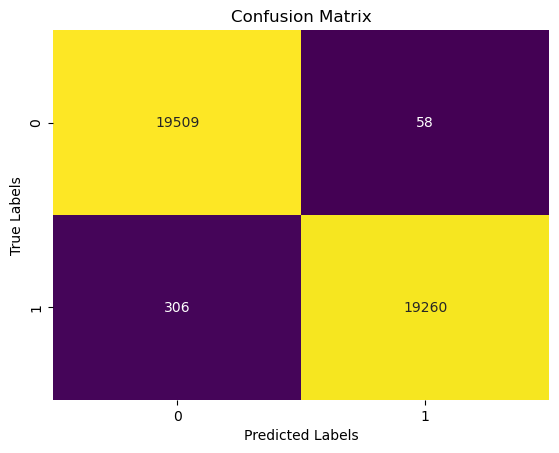

In [62]:
confMat = confusion_matrix(y_test,yPredStacking)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [63]:
print(format(classification_report(y_test,yPredStacking)))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     19567
           1       1.00      0.98      0.99     19566

    accuracy                           0.99     39133
   macro avg       0.99      0.99      0.99     39133
weighted avg       0.99      0.99      0.99     39133



In [64]:
print("f1 Score {}".format(f1_score(y_test,yPredStacking)))
print("Recall Score {}".format(recall_score(y_test,yPredStacking)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredStacking)))
print("Precision Score {}".format(precision_score(y_test,yPredStacking)))

f1 Score 0.9906388231663409
Recall Score 0.984360625574977
Accuracy Score 0.9906983875501495
Precision Score 0.9969976188011181
